# Carga de modulos

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import re

# Data manipulation
import numpy as np
import pandas as pd

# Graphs
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# stopwords for english and spanish
import tensorflow as tf
import unicodedata
import nltk
import spacy
from nltk.corpus import stopwords

# Data preprocessing
from scipy.spatial import distance_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split

# Baseline model
from keras import Model
from keras.layers import Input

# CNN
from keras.layers import Conv2D
from keras.layers import Flatten
from keras.layers import MaxPooling2D

# FNN
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Embedding
from keras.layers import concatenate
from keras.layers import BatchNormalization
from keras.layers import GlobalAveragePooling2D
from keras.layers import LSTM

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model

# Model setup
from keras.models import load_model
from tensorflow.keras.optimizers import Adam
from keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint

# Model performance
from keras import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, \
    mean_absolute_percentage_error

# warnings
import warnings

In [3]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_style("ticks")
odx = pd.IndexSlice
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [4]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

In [5]:
import spacy

def download_spacy_models():
    try:
        spacy.load('es_core_news_sm')
        print("Spanish model already downloaded.")
    except OSError:
        print("Downloading Spanish model...")
        !python -m spacy download es_core_news_sm

    try:
        spacy.load('en_core_web_sm')
        print("English model already downloaded.")
    except OSError:
        print("Downloading English model...")
        !python -m spacy download en_core_web_sm

download_spacy_models()

Spanish model already downloaded.
English model already downloaded.


# Descarga de datos

In [6]:
def read_url(link):
    """ Creates a pandas DataFrame from data online
    - Parameters:
        - link: link to the zipped data
    - Returns:
    """
    import io
    import requests
    import pandas as pd

    # Define URL and extract information
    response = requests.get(link)
    content = response.content
    # Convert into a Pandas DataFrame
    df = pd.read_csv(io.BytesIO(content), sep=',', compression='gzip')

    return df

## Conjunto de datos

In [7]:
listings = read_url('https://data.insideairbnb.com/mexico/df/mexico-city/2025-06-25/data/listings.csv.gz')
# Convert price to numeric (remove $ and ,)
listings['price'] = listings['price'].replace('[\$,]', '', regex=True).astype(float)
print(listings.shape)

(26401, 79)


In [8]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20250625031918,2025-06-26,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Shopping Mall, Interlomas Park and th...",https://a0.muscache.com/pictures/f395ab78-1185...,153786,https://www.airbnb.com/users/show/153786,Dici,2010-06-28,"Mexico City, Mexico","Master in visual arts, film photography & Mark...",NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/00de1...,https://a0.muscache.com/im/pictures/user/00de1...,NaN,1.00,1.00,"['email', 'phone', 'work_email']",t,t,"Mexico City, D.f., Mexico",Cuajimalpa de Morelos,NaN,19.38,-99.27,Entire villa,Entire home/apt,2,1.00,1 bath,1.00,1.00,"[""Kitchen"", ""Resort access"", ""Hot water"", ""Cou...",3799.00,1,7,1.00,1.00,7.00,7.00,1.00,7.00,NaN,t,29,59,89,364,2025-06-26,0,0,0,188,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
1,44616,https://www.airbnb.com/rooms/44616,20250625031918,2025-07-01,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,NaN,https://a0.muscache.com/pictures/251410/ec75fe...,196253,https://www.airbnb.com/users/show/196253,Fernando,2010-08-09,"Mexico City, Mexico",Condesa Haus Rentals offers independent stud...,within an hour,100%,91%,f,https://a0.muscache.com/im/users/196253/profil...,https://a0.muscache.com/im/users/196253/profil...,Condesa,13.00,13.00,"['email', 'phone', 'work_email']",t,t,NaN,Cuauhtémoc,NaN,19.41,-99.18,Entire home,Entire home/apt,14,5.50,5.5 baths,5.00,8.00,"[""Free street parking"", ""Free parking on premi...",18000.00,1,180,1.00,1.00,180.00,180.00,1.00,180.00,NaN,t,29,59,89,360,2025-07-01,65,1,0,179,0,6,108000.00,2011-11-09,2025-01-01,4.59,4.56,4.70,4.87,4.78,4.98,4.47,NaN,f,9,4,2,0,0.39
2,56074,https://www.airbnb.com/rooms/56074,20250625031918,2025-07-01,city scrape,Great space in historical San Rafael,This great apartment is located in one of the ...,Very traditional neighborhood with all service...,https://a0.muscache.com/pictures/3005118/60dac...,265650,https://www.airbnb.com/users/show/265650,Maris,2010-10-19,"Mexico City, Mexico",I am a University Professor now retired after ...,within a few hours,100%,100%,f,https://a0.muscache.com/im/users/265650/profil...,https://a0.muscache.com/im/users/265650/profil...,San Rafael,1.00,5.00,"['email', 'phone']",t,t,"Mexico City, DF, Mexico",Cuauhtémoc,NaN,19.44,-99.16,Entire condo,Entire home/apt,2,1.00,1 bath,1.00,1.00,"[""Dining table"", ""Hot water"", ""Hangers"", ""Esse...",585.00,15,250,15.00,15.00,250.00,250.00,15.00,250.00,NaN,t,3,33,63,338,2025-07-01,84,1,0,157,0,30,17550.00,2011-04-02

## Muestra del conjunto de datos

In [9]:
# tomamos una muestra del dataset 30%
#listings = listings.sample(frac=0.3, random_state=42)

In [10]:
#listings.shape

In [11]:
# save listings sample
# listings.to_csv('/content/drive/MyDrive/DataScience/output/listings_sample_50.csv', index=False)

In [30]:
listings = pd.read_csv('/content/drive/MyDrive/DataScience/output/listings_sample.csv')
listings.shape

(7920, 79)

## Web Scrapping

Descargamos la imagenes de los host, la imagen corresponde a la imagen en general de todo el host,

In [12]:
import os
import requests

def download_and_save_images(df, url_col='picture_url', id_col='id', img_folder='images'):
    if not os.path.exists(img_folder):
        os.makedirs(img_folder)
    image_names = []
    for idx, row in df.iterrows():
        img_url = row[url_col]
        img_name = f"{row[id_col]}.jpg"
        img_path = os.path.join(img_folder, img_name)
        try:
            response = requests.get(img_url, timeout=10)
            response.raise_for_status()
            with open(img_path, 'wb') as f:
                f.write(response.content)
            image_names.append(img_name)
        except Exception as e:
            image_names.append(None)
    df['image_name'] = image_names

# download_and_save_images(listings)

In [13]:
!ls

drive  sample_data


In [ ]:
#!ls /content/drive/MyDrive/DataScience/data/airbnb_images/ | wc -l

In [ ]:
#!du -sh /content/drive/MyDrive/DataScience/data/airbnb_images/

64G	/content/drive/MyDrive/DataScience/data/airbnb_images/


In [14]:
listings.shape

(26401, 79)

In [15]:
IMAGES_PATH = '/content/drive/MyDrive/DataScience/data/airbnb_images/'
images = os.listdir(IMAGES_PATH)
images = pd.DataFrame(images, columns=['image_name'])
images["id"] = images["image_name"].str.replace('.jpg', '').astype(int)
images.head()

,image_name,id
0,1411867311184583126.jpg,1411867311184583126
1,1411812374907250875.jpg,1411812374907250875
2,1411958795041182442.jpg,1411958795041182442
3,1413919298313759755.jpg,1413919298313759755
4,1413926345414120678.jpg,1413926345414120678


In [16]:
listings["id"].dtype, images["id"].dtype

(dtype('int64'), dtype('int64'))

In [17]:
listings = listings.merge(images, on="id", how='left')

Registros en los que no se pudo acceder/descargar a la imagen

In [18]:
listings["image_name"].isnull().sum()

np.int64(547)

Registros que no cuentan con el precio

In [19]:
listings[listings["price"].isnull()].shape

(3274, 80)

Registros que no tiene imagen y precio

In [20]:
listings[listings["image_name"].isnull() & listings["price"].isnull()].shape

(33, 80)

In [21]:
listings[listings["image_name"].isnull() & listings["price"].isnull()].head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,image_name
356,4457362,https://www.airbnb.com/rooms/4457362,20250625031918,2025-07-01,previous scrape,Mexico Vacation Rental Property,"""Excellent house in a residential complex with...",The magical neighborhood of Coyoacán is locate...,https://a0.muscache.com/pictures/05916ad6-21ec...,17468617,https://www.airbnb.com/users/show/17468617,Rafael,2014-06-30,NaN,NaN,within a few hours,100%,65%,f,https://a0.muscache.com/im/pictures/user/4fad6...,https://a0.muscache.com/im/pictures/user/4fad6...,NaN,15.00,31.00,"['email', 'phone']",t,t,"Mexico City, Federal District, Mexico",Coyoacán,NaN,19.34,-99.12,Entire home,Entire home/apt,16,NaN,5 baths,5.00,NaN,"[""Free parking on premises"", ""TV with standard...",NaN,2,365,2.00,2.00,365.00,365.00,2.00,365.00,NaN,t,29,59,89,364,2025-07-01,26,2,0,183,3,12,NaN,2015-01-25,2025-05-25,4.50,4.69,4.69,4.77,4.65,4.85,4.62,NaN,f,15,15,0,0,0.20,NaN
390,7380944,https://www.airbnb.com/rooms/7380944,20250625031918,2025-07-01,previous scrape,Amazing Alojamiento Coyoacan Taxqueña,"You have things to do, places to go, people to...",Ex-Ejido San Francisco Culhuacan is such an ex...,https://a0.muscache.com/pictures/hosting/Hosti...,17468617,https://www.airbnb.com/users/show/17468617,Rafael,2014-06-30,NaN,NaN,within a few hours,100%,65%,f,https://a0.muscache.com/im/pictures/user/4fad6...,https://a0.muscache.com/im/pictures/user/4fad6...,NaN,15.00,31.00,"['email', 'phone']",t,t,"Mexico City, Mexico",Coyoacán,NaN,19.34,-99.12,Entire rental unit,Entire home/apt,4,NaN,2 baths,2.00,NaN,"[""Free parking on premises"", ""Hot water"", ""Ext...",NaN,2,1125,2.00,2.00,1125.00,1125.00,2.00,1125.00,NaN,t,29,59,89,364,2025-07-01,2,0,0,183,0,0,NaN,2019-09-26,2020-02-02,4.50,5.00,5.00,5.00,5.00,5.00,4.50,NaN,f,15,15,0,0,0.03,NaN
498,7886030,https://www.airbnb.com/rooms/7886030,20250625031918,2025-07-01,previous scrape,Premium Stays Coyoacan Mexico,It is the perfect starting point to explore CD...,The northeast area of the Coyoacán City Hall i...,https://a0.muscache.com/pictures/hosting/Hosti...,17468617,https://www.airbnb.com/users/show/17468617,Rafael,2014-06-30,NaN,NaN,within a few hours,100%,65%,f,https://a0.muscache.com/im/pictures/user/4fad6...,https://a0.muscache.com/im/pictures/user/4fad6...,NaN,15.00,31.00,"['email', 'phone']",t,t,"Coyoacan , CDMX, Mexico",Coyoacán,NaN,19.35,-99.13,Entire home,Entire home/apt,14,NaN,3 baths,4.00,NaN,"[""Free street parking"", ""Kitchenette"", ""Carbon...",NaN,2,365,2.00,2.00,365.00,365.00,2.00,365.00,NaN,t,29,59,89,269,2025-07-01,1,1,0,183,1,6,NaN,2024-07-17,2024-07-17,1.00,1.00,2.00,1.00,1.00,4.00,

Removemos los registros que no tienen imagen y precio

In [22]:
listings = listings[~listings["image_name"].isnull() & ~listings["price"].isnull()]
listings.shape

(22613, 80)

Existen imagenes que no se pueden leer, las eliminamos

In [23]:
# validar que todas las imagenes se puedan leer con PIL, usando map en vez de un for loop
from PIL import Image

def validate_image(img_path):
    try:
        img = Image.open(img_path)
        img.verify()  # Verify that it is, in fact an image
        return True
    except (IOError, SyntaxError) as e:
        return False

# listings['image_valid'] = listings['image_name'].map(lambda x: validate_image(os.path.join(IMAGES_PATH, x)))

# estas imagenes por algun motivo no se pueden abrir
broke_img = [1375534954713477213, 1405778580508385877,
             1406079676631590927, 1415487052855439941,
             1419031007665913899, 1419726087265089355,
             1437800743135242037, 1437809302067529400]

# eliminar las imagenes que no se pueden leer
listings[~listings["id"].isin(broke_img)].shape
listings = listings[~listings["id"].isin(broke_img)]
listings.shape

(22605, 80)

# Analisis Exploratorio de Datos

## Limpieza de datos e Ingenieria de Variables

In [24]:
listings["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,price
count,22605.00
mean,2003.64
std,18708.78
min,66.00
1%,217.00
5%,328.00
25%,632.00
50%,1043.00
75%,1652.00
95%,3976.80


TOP 3 registros con el mayor precio

In [25]:
listings[listings["price"] > listings["price"].quantile(0.99)][["listing_url", "price"]].head(3)

,listing_url,price
1,https://www.airbnb.com/rooms/44616,18000.00
55,https://www.airbnb.com/rooms/375032,10500.00
266,https://www.airbnb.com/rooms/5298333,48704.00


Guardamos los datos en una variable auxiliar y los eliminamos del dataset original. es posible ocuparlos mas adelante

In [26]:
print(listings.shape) # antes de eliminar outliers
listings_outliers = listings[listings["price"] > listings["price"].quantile(0.99)]
listings = listings[listings["price"] <= listings["price"].quantile(0.99)]
print(listings.shape) # después de eliminar outliers

(22605, 80)
(22380, 80)


In [27]:
# Histogram of prices with plotly
fig = px.histogram(listings, x='price', nbins=100, title='Distribution of Listing Prices')
fig.update_layout(xaxis_title='Price', yaxis_title='Count', bargap=0.1)
fig.show()

In [28]:
sc = MinMaxScaler()
listings["price_n"] = sc.fit_transform(listings[["price"]])

In [29]:
# Histogram of prices with plotly training and validtion
fig = px.histogram(listings, x='price_n', nbins=100, title='Distribution of Listing Prices')
fig.update_layout(xaxis_title='Price', yaxis_title='Count', bargap=0.1)
fig.show()

In [30]:
y = listings["price_n"].values

In [ ]:
np.save("target_data.npy", y)
target_data = np.load("target_data.npy")
print(target_data.shape)

(22380,)


### Visualizacion de los listings en el mapa

In [32]:
# plot listings by location longitude and latitude, cmap by price
fig = px.scatter_mapbox(listings, lat="latitude", lon="longitude", color="price",
                        size="price", hover_name="name", hover_data=["price", "neighbourhood_cleansed"],
                        color_continuous_scale=px.colors.cyclical.IceFire, size_max=15, zoom=10,
                        mapbox_style="carto-positron", title="Listings by Location Colored by Price")
#fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [33]:
fig = px.histogram(listings, x='neighbourhood_cleansed', title='Distribution of Listings by Neighbourhood')
fig.update_layout(xaxis_title='Neighbourhood', yaxis_title='Count', bargap=0.1)
fig.show()

## Limpieza de datos e Ingenieria de Variables (METADATA)

In [34]:
df_nulls = pd.DataFrame(listings.isnull().sum() / listings.shape[0] * 100).sort_values(by=0, ascending=False)
df_nulls[df_nulls[0] > 0].T

,neighbourhood_group_cleansed,calendar_updated,license,host_neighbourhood,neighbourhood,neighborhood_overview,host_about,host_location,host_response_time,host_response_rate,review_scores_cleanliness,review_scores_communication,review_scores_value,review_scores_accuracy,review_scores_checkin,review_scores_location,review_scores_rating,reviews_per_month,last_review,first_review,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_identity_verified,host_has_profile_pic,host_verifications,host_listings_count,host_picture_url,host_since,host_thumbnail_url,host_name,description,has_availability,bedrooms,beds,minimum_maximum_nights,minimum_minimum_nights,maximum_minimum_nights,maximum_maximum_nights,bathrooms_text,bathrooms
0,100.00,100.00,100.00,47.60,46.77,46.77,41.31,22.98,12.55,12.55,10.47,10.47,10.47,10.47,10.47,10.47,10.46,10.46,10.46,10.46,9.28,5.27,3.83,3.83,3.83,3.83,3.83,3.83,3.83,3.83,3.61,2.53,0.96,0.35,0.10,0.08,0.08,0.08,0.08,0.08,0.03


### Factores del host

In [35]:
# listings.filter(like='host_').columns
host_factors = [
    'host_is_superhost',
    'host_has_profile_pic',
    'host_identity_verified',
    #'host_since_delta',
    'host_since', # new feature: days since host joined
    'host_response_rate',
    'host_acceptance_rate',
    'host_total_listings_count',
    'host_listings_count'
]

In [36]:
listings[host_factors].isnull().sum() / listings[host_factors].shape[0] * 100

,0
host_is_superhost,5.27
host_has_profile_pic,3.83
host_identity_verified,3.83
host_since,3.83
host_response_rate,12.55
host_acceptance_rate,9.28
host_total_listings_count,3.83
host_listings_count,3.83


In [37]:
listings["host_is_superhost"] = listings["host_is_superhost"].map({'t': 1, 'f': 0})
listings["host_is_superhost"] = listings["host_is_superhost"].fillna(2) # 2 means unknown

listings["host_has_profile_pic"] = listings["host_has_profile_pic"].map({'t': 1, 'f': 0})
listings["host_has_profile_pic"] = listings["host_has_profile_pic"].fillna(2) # 2 means unknown

listings["host_identity_verified"] = listings["host_identity_verified"].map({'t': 1, 'f': 0})
listings["host_identity_verified"] = listings["host_identity_verified"].fillna(2) # 2 means unknown

listings["host_since"]  = pd.to_datetime(listings["host_since"], errors='coerce') # create delta days from today
listings["host_since_delta"] = (pd.Timestamp('2025-06-25') - listings["host_since"]).dt.days
listings["host_since_delta"] = listings["host_since_delta"].fillna(listings["host_since_delta"].median())

listings["host_response_rate"] = listings["host_response_rate"].str.replace('%', '').astype(float)
listings["host_response_rate"] = listings["host_response_rate"].fillna(listings["host_response_rate"].median())

listings["host_acceptance_rate"] = listings["host_acceptance_rate"].str.replace('%', '').astype(float)
listings["host_acceptance_rate"] = listings["host_acceptance_rate"].fillna(listings["host_acceptance_rate"].median())

listings["host_total_listings_count"] = listings["host_total_listings_count"].fillna(1) # assume 1 because they have a listing

listings["host_listings_count"] = listings["host_listings_count"].fillna(1) # assume 1 because they have a listing

Cambio a variables nuevas

In [38]:
host_factors = [  x if x != "host_since" else "host_since_delta" for x in host_factors ]
host_factors

['host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'host_since_delta',
 'host_response_rate',
 'host_acceptance_rate',
 'host_total_listings_count',
 'host_listings_count']

### Factores de funcion

In [39]:
function_factors = [
    'accommodates', # number of guests
    'bathrooms',
    'bedrooms',
    'beds',
    'property_type',
    'amenities',
    'room_type',
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
]

In [40]:
listings[function_factors].isna().sum() / listings[function_factors].shape[0] * 100

,0
accommodates,0.00
bathrooms,0.03
bedrooms,0.35
beds,0.10
property_type,0.00
amenities,0.00
room_type,0.00
calculated_host_listings_count,0.00
calculated_host_listings_count_entire_homes,0.00
calculated_host_listings_count_private_rooms,0.00


In [41]:
def extract_amenities(amenities_str):
    amenities_str = str(amenities_str)
    amenities_list = []
    if pd.isna(amenities_str):
        return None
    amenities_str = amenities_str.replace('"', '').replace('[', '').replace(']', '')
    amenities_list = [amenity.strip() for amenity in amenities_str.split(',')]
    return len(amenities_list)

In [42]:
listings["bathrooms"] = listings["bathrooms"].fillna(0) # shared
listings["bedrooms"] = listings["bedrooms"].fillna(0) # shared bedroom
listings["beds"] = listings["beds"].fillna(1) # at least one bed

listings["amenities_n"] = listings["amenities"].map(lambda x: extract_amenities(x))
listings["bathrooms"] = listings["bathrooms"].astype(int)
listings["bedrooms"] = listings["bedrooms"].astype(int)
listings["beds"] = listings["beds"].astype(int)

# Cambio a variables nuevas
function_factors = [x if x != "amenities" else "amenities_n" for x in function_factors]

### Factores de reputacion

In [43]:
reputation_factors = [
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating', # this is general
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'first_review', # delta
    'last_review', # delta
    'reviews_per_month'
]

In [44]:
listings['reviews_per_month'] = listings['reviews_per_month'].fillna(listings['reviews_per_month'].median())
listings['review_scores_rating'] = listings['review_scores_rating'].fillna(listings['review_scores_rating'].median())
listings['review_scores_accuracy'] = listings['review_scores_accuracy'].fillna(listings['review_scores_accuracy'].median())
listings['review_scores_cleanliness'] = listings['review_scores_cleanliness'].fillna(listings['review_scores_cleanliness'].median())
listings['review_scores_checkin'] = listings['review_scores_checkin'].fillna(listings['review_scores_checkin'].median())
listings['review_scores_communication'] = listings['review_scores_communication'].fillna(listings['review_scores_communication'].median())
listings['review_scores_location'] = listings['review_scores_location'].fillna(listings['review_scores_location'].median())
listings['review_scores_value'] = listings['review_scores_value'].fillna(listings['review_scores_value'].median())
listings['reviews_per_month'] = listings['reviews_per_month'].fillna(listings['reviews_per_month'].median())

listings["first_review"]  = pd.to_datetime(listings["first_review"], errors='coerce') # create delta days from today
listings["first_review"] = (pd.Timestamp('2025-06-25') - listings["first_review"]).dt.days
listings["first_review"] = listings["first_review"].fillna(listings["first_review"].median())

listings["last_review"]  = pd.to_datetime(listings["last_review"], errors='coerce') # create delta days from today
listings["last_review"] = (pd.Timestamp('2025-06-25') - listings["last_review"]).dt.days
listings["last_review"] = listings["last_review"].fillna(listings["last_review"].median())

In [45]:
listings[reputation_factors].isnull().sum() / listings[reputation_factors].shape[0] * 100

,0
number_of_reviews,0.00
reviews_per_month,0.00
review_scores_rating,0.00
review_scores_accuracy,0.00
review_scores_cleanliness,0.00
review_scores_checkin,0.00
review_scores_communication,0.00
review_scores_location,0.00
review_scores_value,0.00
number_of_reviews_ltm,0.00


In [46]:
listings["number_of_reviews"] = listings["number_of_reviews"].astype(int)
listings["reviews_per_month"] = listings["reviews_per_month"].astype(int)
listings["number_of_reviews_ltm"] = listings["number_of_reviews_ltm"].astype(int)
listings["number_of_reviews_l30d"] = listings["number_of_reviews_l30d"].astype(int)
listings["first_review"] = listings["first_review"].astype(int)
listings["last_review"] = listings["last_review"].astype(int)
listings["reviews_per_month"] = listings["reviews_per_month"].astype(int)

listings["review_scores_rating"] = listings["review_scores_rating"].astype(float)
listings["review_scores_accuracy"] = listings["review_scores_accuracy"].astype(float)
listings["review_scores_cleanliness"] = listings["review_scores_cleanliness"].astype(float)
listings["review_scores_checkin"] = listings["review_scores_checkin"].astype(float)
listings["review_scores_communication"] = listings["review_scores_communication"].astype(float)
listings["review_scores_location"] = listings["review_scores_location"].astype(float)
listings["review_scores_value"] = listings["review_scores_value"].astype(float)
listings["review_scores_cleanliness"] = listings["review_scores_cleanliness"].astype(float)

### Factores de ubicacion

In [47]:
location_factors = [
    'neighbourhood_cleansed',
    'latitude',
    'longitude'
]

In [48]:
listings[location_factors].isnull().sum()

,0
neighbourhood_cleansed,0
latitude,0
longitude,0


### Factores misellaneous

In [49]:
misellaneous_factors = [
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    'has_availability',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'instant_bookable'
]

In [50]:
listings["has_availability"] = listings["has_availability"].fillna('f')

In [51]:
listings["has_availability"] = listings["has_availability"].map({'t': 1, 'f': 0})

In [52]:
listings["instant_bookable"] = listings["instant_bookable"].map({'t': 1, 'f': 0})

In [81]:
listings["minimum_minimum_nights"] = listings["minimum_minimum_nights"].fillna(listings["minimum_minimum_nights"].median())
listings["maximum_minimum_nights"] = listings["maximum_minimum_nights"].fillna(listings["maximum_minimum_nights"].median())
listings["minimum_maximum_nights"] = listings["minimum_maximum_nights"].fillna(listings["minimum_maximum_nights"].median())
listings["maximum_maximum_nights"] = listings["maximum_maximum_nights"].fillna(listings["maximum_maximum_nights"].median())

In [82]:
listings[misellaneous_factors].isnull().sum()

,0
minimum_nights,0
maximum_nights,0
minimum_minimum_nights,0
maximum_minimum_nights,0
minimum_maximum_nights,0
maximum_maximum_nights,0
minimum_nights_avg_ntm,0
maximum_nights_avg_ntm,0
has_availability,0
availability_30,0


### Variables categoricas y numericas

In [83]:
listings[ host_factors + function_factors + reputation_factors + location_factors + misellaneous_factors ].head()

,host_is_superhost,host_has_profile_pic,host_identity_verified,host_since_delta,host_response_rate,host_acceptance_rate,host_total_listings_count,host_listings_count,accommodates,bathrooms,bedrooms,beds,property_type,amenities_n,room_type,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,reviews_per_month,neighbourhood_cleansed,latitude,longitude,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,instant_bookable
0,0.00,1.00,1.00,5476.00,100.00,99.00,1.00,1.00,2,1,1,1,21,12,0,1,1,0,0,0,1,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,0,850,28,1,3,19.38,-99.27,1,7,1.00,1.00,7.00,7.00,1.00,7.00,1,29,59,89,364,0
2,0.00,1.00,1.00,5363.00,100.00,100.00,5.00,1.00,2,1,1,1,8,28,0,1,1,0,0,84,0,4.87,4.95,4.88,4.98,4.94,4.76,4.79,1,0,5198,118,0,4,19.44,-99.16,15,250,15.00,15.00,250.00,250.00,15.00,250.00,1,3,33,63,338,0
3,0.00,1.00,1.00,5286.00,100.00,47.00,4.00,3.00,4,1,2,2,17,21,0,2,2,0,0,50,0,4.90,4.82,4.76,4.94,4.92,4.98,4.92,1,0,4969,238,0,4,19.41,-99.17,2,30,2.00,2.00,30.00,30.00,2.00,30.00,1,3,4,32,267,0
4,1.00,1.00,1.00,5419.00,100.00,85.00,4.00,3.00,2,1,1,1,17,51,0,3,2,1,0,132,0,4.92,4.91,4.96,4.96,4.98,4.96,4.92,8,0,4880,179,0,2,19.35,-99.16,3,180,3.00,4.00,180.00,180.00,3.40,180.00,1,10,25,25,211,0
6,1.00,1.00,1.00,5102.00,93.00,93.00,6.00,5.00,16,5,5,10,12,48,0,5,5,0,0,383,2,4.88,4.91,4.83,4.91,4.88,4.75,4.90,31,0,5081,29,2,9,19.41,-99.19,2,365,2.00,2.00,365.00,365.00,2.00,365.00,1,2,11,28,177,0


In [84]:
listings[ host_factors + function_factors + reputation_factors + location_factors + misellaneous_factors ].select_dtypes(include='object').shape

(22380, 0)

In [85]:
listings[ host_factors + function_factors + reputation_factors + location_factors + misellaneous_factors ].shape

(22380, 50)

In [86]:
metadata_cols = host_factors + function_factors + reputation_factors + location_factors + misellaneous_factors

In [87]:
from sklearn.preprocessing import LabelEncoder

property_type_le = LabelEncoder()
room_type_le = LabelEncoder()
neighbourhood_cleansed_le = LabelEncoder()

property_type_y = property_type_le.fit_transform(listings["property_type"])
room_type_y = room_type_le.fit_transform(listings["room_type"])
neighbourhood_cleansed_y = neighbourhood_cleansed_le.fit_transform(listings["neighbourhood_cleansed"])

# property_type_y = to_categorical(property_type_y)
# room_type_y = to_categorical(room_type_y)
# neighbourhood_cleansed_y = to_categorical(neighbourhood_cleansed_y)

listings["property_type"] = property_type_y
listings["room_type"] = room_type_y
listings["neighbourhood_cleansed"] = neighbourhood_cleansed_y

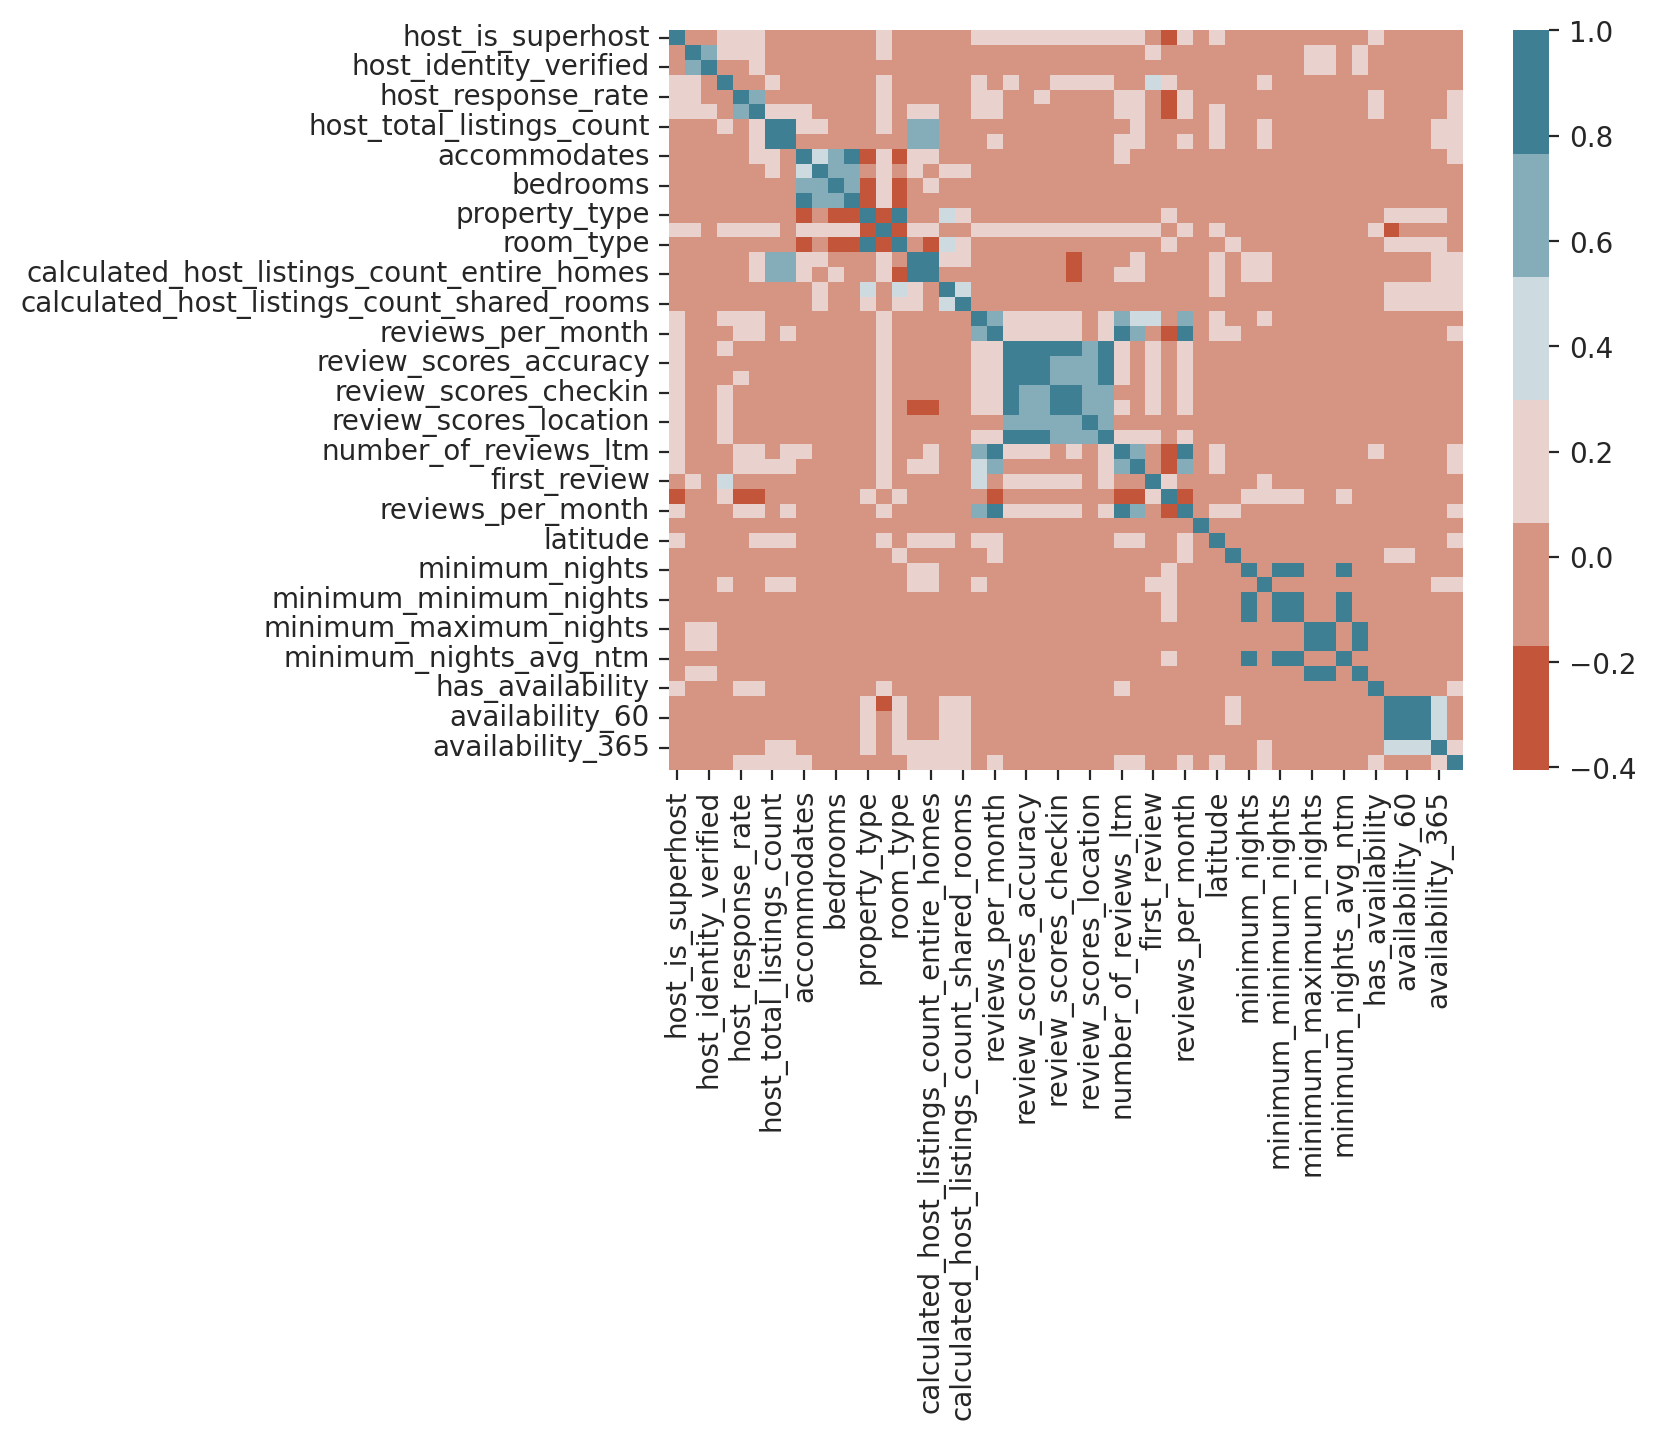

In [88]:
sns.heatmap(listings[ metadata_cols
                     ].corr(),
                     cmap=sns.diverging_palette(h_neg=20, h_pos=220))
plt.show()

In [89]:
listings[metadata_cols].head()

,host_is_superhost,host_has_profile_pic,host_identity_verified,host_since_delta,host_response_rate,host_acceptance_rate,host_total_listings_count,host_listings_count,accommodates,bathrooms,bedrooms,beds,property_type,amenities_n,room_type,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,reviews_per_month,neighbourhood_cleansed,latitude,longitude,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,instant_bookable
0,0.00,1.00,1.00,5476.00,100.00,99.00,1.00,1.00,2,1,1,1,21,12,0,1,1,0,0,0,1,4.84,4.88,4.85,4.92,4.92,4.92,4.80,0,0,850,28,1,3,19.38,-99.27,1,7,1.00,1.00,7.00,7.00,1.00,7.00,1,29,59,89,364,0
2,0.00,1.00,1.00,5363.00,100.00,100.00,5.00,1.00,2,1,1,1,8,28,0,1,1,0,0,84,0,4.87,4.95,4.88,4.98,4.94,4.76,4.79,1,0,5198,118,0,4,19.44,-99.16,15,250,15.00,15.00,250.00,250.00,15.00,250.00,1,3,33,63,338,0
3,0.00,1.00,1.00,5286.00,100.00,47.00,4.00,3.00,4,1,2,2,17,21,0,2,2,0,0,50,0,4.90,4.82,4.76,4.94,4.92,4.98,4.92,1,0,4969,238,0,4,19.41,-99.17,2,30,2.00,2.00,30.00,30.00,2.00,30.00,1,3,4,32,267,0
4,1.00,1.00,1.00,5419.00,100.00,85.00,4.00,3.00,2,1,1,1,17,51,0,3,2,1,0,132,0,4.92,4.91,4.96,4.96,4.98,4.96,4.92,8,0,4880,179,0,2,19.35,-99.16,3,180,3.00,4.00,180.00,180.00,3.40,180.00,1,10,25,25,211,0
6,1.00,1.00,1.00,5102.00,93.00,93.00,6.00,5.00,16,5,5,10,12,48,0,5,5,0,0,383,2,4.88,4.91,4.83,4.91,4.88,4.75,4.90,31,0,5081,29,2,9,19.41,-99.19,2,365,2.00,2.00,365.00,365.00,2.00,365.00,1,2,11,28,177,0


### Escalado de datos

In [ ]:
# escalado de datos
from sklearn.preprocessing import MinMaxScaler
import numpy as np

structured_data = np.hstack([listings[ metadata_cols ].values])

sc = MinMaxScaler()

structured_data = sc.fit_transform(structured_data)

np.save("structured_data.npy", structured_data)

In [91]:
print("NaNs en structured_data:", np.isnan(structured_data).any())

NaNs en structured_data: False


In [92]:
print(structured_data.shape)

(22380, 50)


## Limpieza de datos e Ingenieria de Variables (TEXT)

In [65]:
listings["description"].isnull().sum()

np.int64(567)

In [66]:
listings["description"] = listings["description"].astype(str)

In [67]:
listings["description"].isnull().sum()

np.int64(0)

In [68]:
listings["description"]

,description
0,"Dentro de Villa un estudio de arte con futon, ..."
2,This great apartment is located in one of the ...
3,"Comfortably furnished, sunny, 2 bedroom apt., ..."
4,COYOACAN designer studio quiet & safe! well eq...
6,Welcome to Your Home in Mexico City<br />We ha...
...,...
26396,New 60-meter luxury apartment with two spaciou...
26397,Experience elevated business travel in our bea...
26398,"Apartment in the heart of Mexico City, 2 minut..."
26399,Stay in a chic loft inside a restored historic...


In [69]:
def clean_text(text, pattern="[^a-zA-Z0-9 ]"):
    cleaned_text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore')
    cleaned_text = re.sub(pattern, " ", cleaned_text.decode("utf-8"), flags=re.UNICODE)
    cleaned_text = u' '.join(cleaned_text.lower().split())
    return cleaned_text

In [70]:
nltk.download('stopwords')
stop_words_en = set(stopwords.words('english'))
stop_words_es = set(stopwords.words('spanish'))

# use english and spanish
stop_words = [clean_text(x) for x in stop_words_en.union(stop_words_es)]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


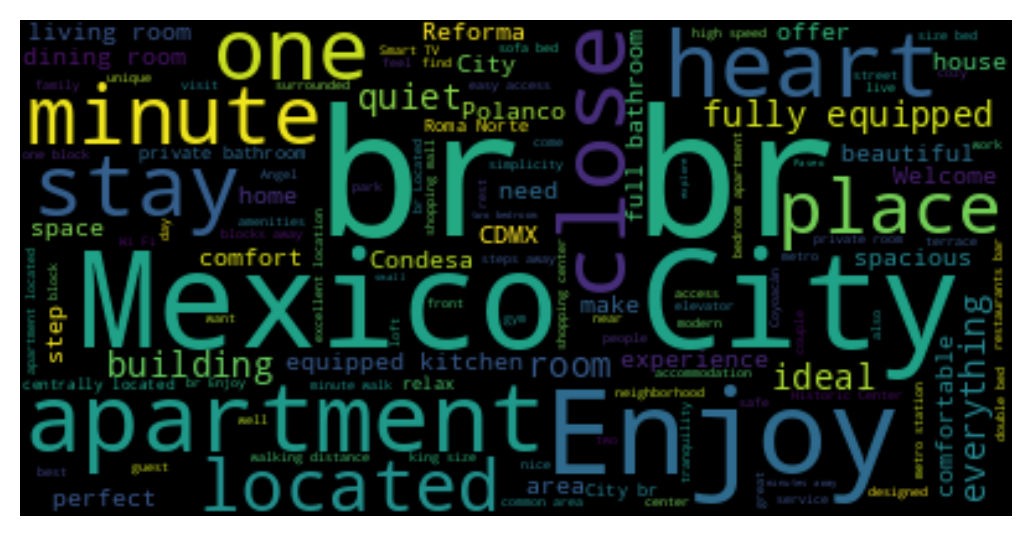

In [71]:
# generate word cloud
from wordcloud import WordCloud

# Start with one review:
# text = listings.description[0]
text = " ".join(listings["description"].astype(str))

# Create and generate a word cloud image:
wordcloud = WordCloud(stopwords=stop_words).generate(text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Eliminamos URLS

In [72]:
url_pattern = r"((http://)[^ ]*|(https://)[^ ]*|( www\.)[^ ]*)"
listings["description"] = listings["description"].map(lambda text: re.sub(url_pattern, '', text))

### Removemos br

In [73]:
# remover br
listings["description"] = listings["description"].map(lambda text: text.replace('<br>', ''))
listings["description"] = listings["description"].map(lambda text: text.replace('br', ''))

# remover salto de linea
listings["description"] = listings["description"].map(lambda text: text.replace('\n', ''))

### Normalizacion de texto

In [74]:
listings["description"] = listings["description"].map(clean_text)

### Eliminamos stopswords

In [75]:
# stopwords english
words_to_remove = ['for','by','with','against','shan','dont', 'don', 'didn', 'ain', 'couldn',
                   'couldnt', 'didnt','arent','havent','werent', 'until', 'aint', 'but',
                   'off','out']

ls_stopwords = [word for word in map(clean_text, stop_words ) if word not in words_to_remove]

listings["description"] = listings["description"].str.split().map(lambda words: [word for word in words if word not in ls_stopwords]).str.join(" ")

### Lemmatizado

In [76]:
nlp_en = spacy.load('en_core_web_sm', disable = ['parser','ner'])
nlp_es = spacy.load('es_core_news_sm', disable = ['parser','ner'])

listings["description"] = listings["description"].map(lambda sentence: [token.lemma_ for token in nlp_en(sentence)]).str.join(" ")
listings["description"] = listings["description"].map(lambda sentence: [token.lemma_ for token in nlp_es(sentence)]).str.join(" ")

### Vectorizacion

In [93]:
listings["words"] = listings["description"].str.split()

In [94]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=listings["words"].str.len(), nbinsx=100))
fig.update_layout(title="Sample length distribution", xaxis_title="Length of a sample", yaxis_title="Number of samples")
fig.show()

In [95]:
all_words = listings["words"]

In [96]:
MAX_NB_WORDS = 1000
MAX_SEQUENCE_LENGTH = 250
EMBEDDING_DIM = 50

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=MAX_NB_WORDS,
                                                  filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~',
                                                  lower=True)
tokenizer.fit_on_texts(all_words.values)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 13112 unique tokens.


In [97]:
text_data = tokenizer.texts_to_sequences(listings["words"].values)

In [98]:
len(text_data)

22380

### Padding

In [99]:
text_data = pad_sequences(text_data, maxlen=MAX_SEQUENCE_LENGTH)
print('Shape of data tensor:', text_data.shape)

Shape of data tensor: (22380, 250)


In [100]:
text_data

array([[  0,   0,   0, ...,   0,   0, 314],
       [  0,   0,   0, ..., 227, 254,   3],
       [  0,   0,   0, ...,  61, 149, 233],
       ...,
       [  0,   0,   0, ...,  15, 709,   2],
       [  0,   0,   0, ...,  85, 249,  88],
       [  0,   0,   0, ..., 473,  10, 532]], dtype=int32)

In [101]:
np.save("/content/drive/MyDrive/DataScience/output/CNN_multimodal/text_data.npy", text_data)
text_data = np.load("/content/drive/MyDrive/DataScience/output/CNN_multimodal/text_data.npy")
print(text_data.shape)

(22380, 250)


## Limpieza de datos e Ingenieria de Variables (IMAGES)

In [102]:
listings["image_name"].isnull().sum()

np.int64(0)

In [103]:
listings["image_name"] = listings["image_name"].astype(str)

In [104]:
listings[["id", "price", "image_name"]].head()

,id,price,image_name
0,35797,3799.00,35797.jpg
2,56074,585.00,56074.jpg
3,67703,1696.00,67703.jpg
4,70644,1004.00,70644.jpg
6,165772,4071.00,165772.jpg


In [105]:
listings["image_path"] = listings["image_name"].map(lambda x: os.path.join(IMAGES_PATH, x))

In [106]:
TARGET_SIZE = (100, 100)
BATCH_SIZE = 32
CLASS_MODE = 'raw'

In [107]:
def load_and_preprocess_image(path):
    img = Image.open(path).convert('RGB')
    img = img.resize((128, 128))
    img_array = np.array(img) / 255.0
    return img_array

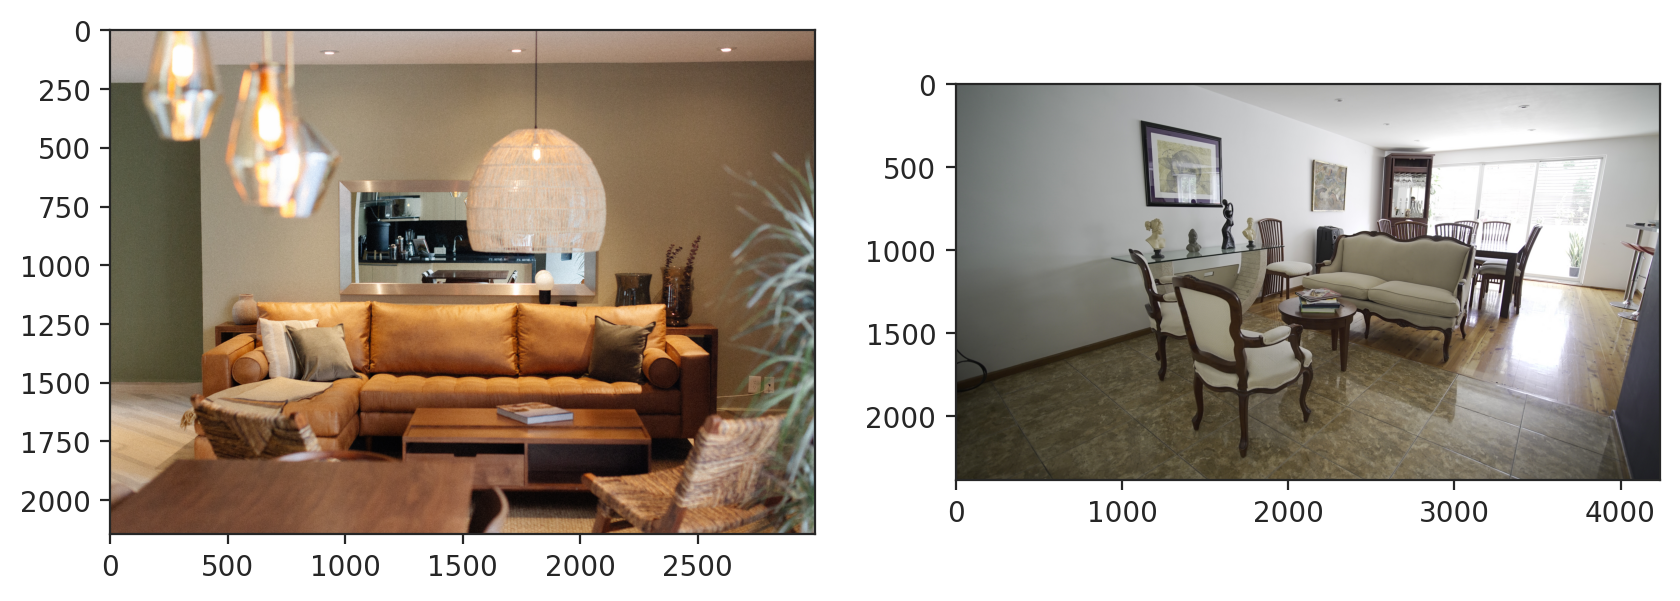

In [108]:
# imagen de la casa mas cara y barata
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(plt.imread(listings["image_path"].sample().values[0]))
plt.subplot(1, 2, 2)
plt.imshow(plt.imread(listings["image_path"].sample().values[0]))
plt.show()

In [ ]:
image_data = np.array([load_and_preprocess_image(p) for p in listings['image_path']])

In [ ]:
np.save("/content/drive/MyDrive/DataScience/output/CNN_multimodal/images_data.npy", image_data)

In [ ]:
# Luego, en otra sesión o script, puedes volver a cargar:
images_data = np.load("/content/drive/MyDrive/DataScience/output/CNN_multimodal/images_data.npy")
print(images_data.shape)

(6728, 128, 128, 3)


## Conjunto de entrenamiento y validacion

In [3]:
target_data = np.load("/content/drive/MyDrive/DataScience/output/target_data.npy")
# structured_data = np.load("/content/drive/MyDrive/DataScience/output/structured_data.npy")
structured_data = np.load("/content/drive/MyDrive/DataScience/output/structured_data_scaled.npy")
text_data = np.load("/content/drive/MyDrive/DataScience/output/text_data.npy")
image_data = np.load("/content/drive/MyDrive/DataScience/output/images_data.npy")

In [6]:
print("NaNs en target_data:", np.isnan(target_data).any())
print("NaNs en structured_data:", np.isnan(structured_data).any())
print("NaNs en text_data:", np.isnan(text_data).any())
print("NaNs en image_data:", np.isnan(image_data).any())

NaNs en target_data: False
NaNs en structured_data: False
NaNs en text_data: False
NaNs en image_data: False


In [5]:
structured_data = np.nan_to_num(structured_data)

In [7]:
# División en conjuntos de entrenamiento y prueba
X_train_structured, X_test_structured, \
X_train_text, X_test_text, \
X_train_image, X_test_image, \
y_train, y_test = train_test_split(
    structured_data, text_data, image_data, target_data, test_size=0.2, random_state=42
)

In [8]:
del target_data
del structured_data
del text_data
del image_data

In [9]:
import gc
gc.collect()

102

Para los embeddings es necesario  aplicar el ravel

In [ ]:
# values to array numpy
#X_train_text = np.array(X_train["embeddings"].tolist())
#X_test_text = np.array(X_test["embeddings"].tolist())

## Modelado

### Rama para datos estructurados

In [10]:
input_structured = Input(shape=(X_train_structured.shape[1],), name='input_estructurado')
dense_structured = Dense(32, activation='relu')(input_structured)
dense_structured = Dense(16, activation='relu')(dense_structured)

### Rama para datos de texto

In [11]:
input_text = Input(shape=(X_train_text.shape[1],), name='input_texto')
embedding_text = Embedding(input_dim=1000, output_dim=128)(input_text)
lstm_text = LSTM(64)(embedding_text)

### Rama para datos de imagen

In [12]:
input_image = Input(shape=(128, 128, 3), name='input_imagen')
conv_image = Conv2D(32, (3, 3), activation='relu')(input_image)
pool_image = MaxPooling2D((2, 2))(conv_image)
conv_image = Conv2D(64, (3, 3), activation='relu')(pool_image)
pool_image = MaxPooling2D((2, 2))(conv_image)
flat_image = Flatten()(pool_image)
dense_image = Dense(64, activation='relu')(flat_image)

### Concatenacion de las ramas

In [13]:
concatenated = concatenate([dense_structured, lstm_text, dense_image])

### Capas finales de prediccion

In [14]:
final_dense = Dense(64, activation='relu')(concatenated)
output = Dense(1, name='output_valor')(final_dense)

### Modelo final

In [15]:
model = Model(
    inputs=[input_structured, input_text, input_image],
    outputs=output
)

### Compilacion del modelo

In [16]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_imagen        │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_imagen[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_estructurado  │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_texto         │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,632 │ input_estructura… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 128)  │    128,000 │ input_texto[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 57600)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │  3,686,464 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ lstm[0][0],       │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_valor        │ (None, 1)         │         65 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,894,769 (14.86 MB)

 Trainable params: 3,894,769 (14.86 MB)

 Non-trainable params: 0 (0.00 B)

### Metricas de performance

In [17]:
kmetrics = [
    metrics.RootMeanSquaredError(name='rms'),
    metrics.MeanAbsoluteError(name='mae'),
    metrics.MeanAbsolutePercentageError(name="pema")
]

### Call backs

In [18]:
early_stopping = EarlyStopping(
    monitor='val_mae',
    patience=5,
    min_delta=0.0001,
    mode='min',
    restore_best_weights=True
    )

In [19]:
checkpoint = ModelCheckpoint('models/houses/model.keras',
                             save_best_only=True,
                             save_weights_only=False,
                             monitor='val_mae')

### Entrenamiento del modelo

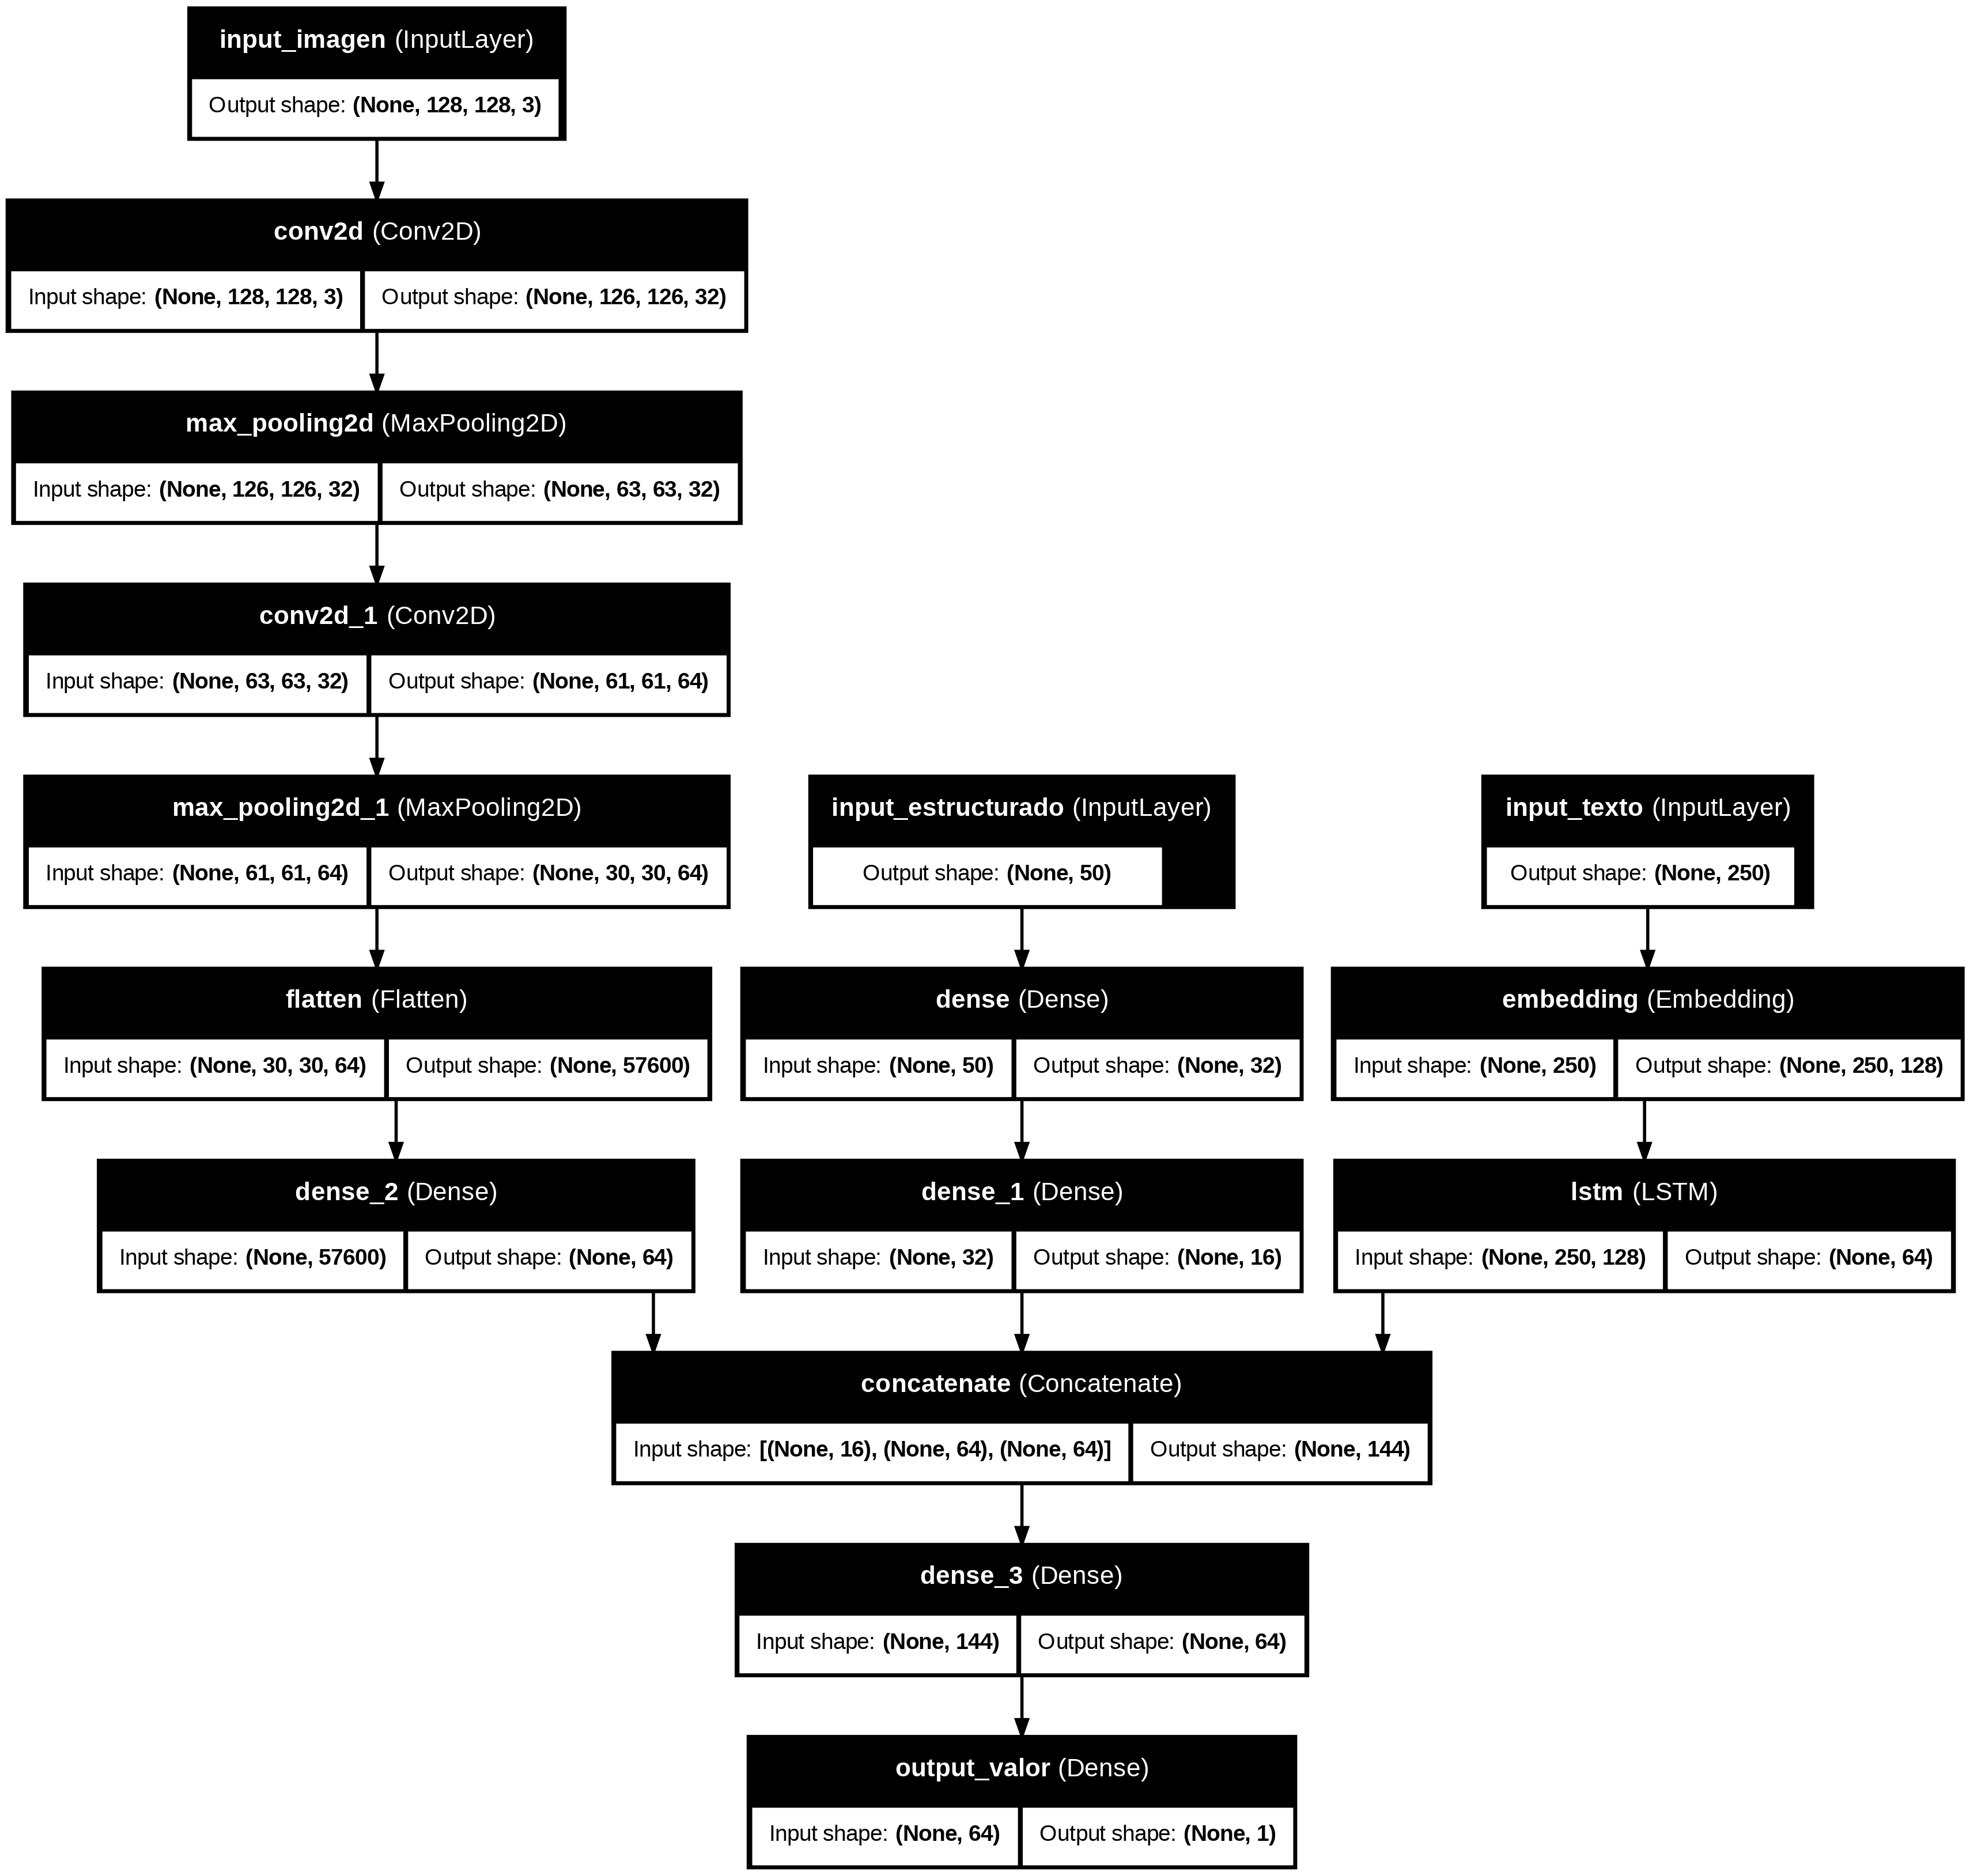

In [20]:
plot_model(model, "house_pricing.png", show_shapes=True, show_layer_names=True)

In [21]:
# Show layers of the model
for layer in model.layers:
    print(layer.name)

input_imagen
conv2d
max_pooling2d
conv2d_1
input_estructurado
input_texto
max_pooling2d_1
dense
embedding
flatten
dense_1
lstm
dense_2
concatenate
dense_3
output_valor


In [22]:
history = model.fit(
    {
        'input_estructurado': X_train_structured,
        'input_texto': X_train_text,
        'input_imagen': X_train_image
    },
    y_train.astype(np.float32),
    validation_data=(
        {
            'input_estructurado': X_test_structured,
            'input_texto': X_test_text,
            'input_imagen': X_test_image
        },
        y_test.astype(np.float32)
    ),
    epochs=20,
    batch_size=16,
    verbose=1,
    #callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0354 - val_loss: 0.0078
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0082 - val_loss: 0.0068
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0045 - val_loss: 0.0073
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0026 - val_loss: 0.0068
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0017 - val_loss: 0.0065
Epoch 6/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0013 - val_loss: 0.0068
Epoch 7/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0010 - val_loss: 0.0073
Epoch 8/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0010 - val_loss: 0.0066
Epoch 9/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 9.3144e-04 - val_loss: 0.0066
Epoch 10/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 9.4370e-04 - val_loss: 0.0067
Epoch 11/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 8.0216e-04 - val_loss: 0.0068
Epoch 12/20
337/337 ━━━━━━━

In [25]:
# save the model
model.save("/content/house_pricing.h5")

In [26]:
model.save("/content/model.keras")

### Analisis de resultados

In [23]:
df_res = pd.DataFrame(history.history)

In [24]:
# plot results
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_res.index, y=df_res["loss"], name="loss"))
fig.add_trace(go.Scatter(x=df_res.index, y=df_res["val_loss"], name="val_loss"))
fig.update_layout(title="Loss", xaxis_title="Epoch", yaxis_title="Loss")
fig.show()

### Mejor modelo

In [27]:
best_model = load_model("/content/model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning:

Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 



In [31]:
loss = best_model.evaluate([X_test_structured, X_test_text, X_test_image], y_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0059


In [32]:
from sklearn.preprocessing import MinMaxScaler
listings = listings[listings["price"] <= listings["price"].quantile(0.99)]
sc = MinMaxScaler()
listings["price_n"] = sc.fit_transform(listings[["price"]])

In [33]:
y_hat = best_model.predict([X_test_structured, X_test_text, X_test_image])
y_hat = sc.inverse_transform(y_hat)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [34]:
y_true = sc.inverse_transform(y_test.reshape(-1, 1))

In [35]:
df_y = pd.DataFrame(data=zip(y_true.ravel(), y_hat.ravel()), columns=["y_true", "y_hat"])

### Metricas

In [36]:
print("r2_score: ", r2_score(y_true=y_true, y_pred=y_hat))
print("mean_absolute_error: ", mean_absolute_error(y_true=y_true, y_pred=y_hat))
print("mean_squared_error: ", mean_squared_error(y_true=y_true, y_pred=y_hat))
print("mean_absolute_percentage_error: ", mean_absolute_percentage_error(y_true=y_true, y_pred=y_hat))

r2_score:  0.42136831943810893
mean_absolute_error:  481.07177091884756
mean_squared_error:  639012.2498298843
mean_absolute_percentage_error:  0.4512273563595083
